# Modeling — Dự báo Nguy cơ Trả hàng (Order Return Prediction)

Notebook này xây dựng và đánh giá các mô hình phân loại nhị phân cho bài toán
dự đoán trả hàng ở cấp **đơn hàng** (`order_id`).

## Pipeline

```
1. Load Features → 2. Encode Categoricals → 3. Train/Test Split (Temporal)
   → 4. Baseline Models → 5. Advanced Models (LightGBM, XGBoost)
   → 6. Evaluation (AUC-ROC, F1, PR Curve) → 7. Feature Importance (SHAP)
   → 8. Error Analysis → 9. Cross-Validation
```

## 1. Khởi tạo Môi trường

In [21]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
DATA_DIR = r'./datathon-2026-round-1'
print('Thư viện đã sẵn sàng!')

Thư viện đã sẵn sàng!


## 2. Tải dữ liệu đã Feature Engineering

In [22]:
# Tải feature config
with open(os.path.join(DATA_DIR, 'return_prediction_feature_config.json'), 'r') as f:
    config = json.load(f)

ID_COLS = config['id_columns']
TARGET_COL = config['target_column']
NUMERIC_FEATURES = config['numeric_features']
CATEGORICAL_FEATURES = config['categorical_features']
CUTOFF_DATE = config['cutoff_date']

print(f'Feature config loaded!')
print(f'  Granularity: {config.get("granularity", "order_id")}')
print(f'  Numeric features: {len(NUMERIC_FEATURES)}')
print(f'  Categorical features: {len(CATEGORICAL_FEATURES)}')
print(f'  Cutoff date: {CUTOFF_DATE}')

Feature config loaded!
  Granularity: order_id
  Numeric features: 49
  Categorical features: 9
  Cutoff date: 2022-07-01


In [23]:
# Tải dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'return_prediction_features.csv'), parse_dates=['order_date'])
print(f'Dataset: {df.shape[0]:,} orders × {df.shape[1]} columns')
print(f'Target distribution:')
print(df[TARGET_COL].value_counts())
print(f'Return rate: {df[TARGET_COL].mean()*100:.2f}%')

Dataset: 552,858 orders × 62 columns
Target distribution:
is_returned
0    516796
1     36062
Name: count, dtype: int64
Return rate: 6.52%


## 3. Tiền xử lý dữ liệu

In [24]:
# Label Encoding cho categorical features
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = df[col].astype(str).fillna('unknown')
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Fill NaN cho numeric features
for col in NUMERIC_FEATURES:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print(f'Encoding hoàn tất cho {len(label_encoders)} categorical features')

Encoding hoàn tất cho 9 categorical features


In [25]:
# Temporal Split
cutoff = pd.to_datetime(CUTOFF_DATE)
train_mask = df['order_date'] < cutoff
test_mask = df['order_date'] >= cutoff

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

X_train = df.loc[train_mask, ALL_FEATURES].copy()
y_train = df.loc[train_mask, TARGET_COL].copy()
X_test = df.loc[test_mask, ALL_FEATURES].copy()
y_test = df.loc[test_mask, TARGET_COL].copy()

# scale_pos_weight cho class imbalance
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'=== TEMPORAL SPLIT ===')
print(f'Train: {X_train.shape[0]:,} orders ({y_train.mean()*100:.2f}% return)')
print(f'Test:  {X_test.shape[0]:,} orders ({y_test.mean()*100:.2f}% return)')
print(f'Features: {len(ALL_FEATURES)}')
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

=== TEMPORAL SPLIT ===
Train: 540,277 orders (6.52% return)
Test:  12,581 orders (6.61% return)
Features: 58
scale_pos_weight = 14.34


## 4. Baseline Models

In [26]:
# Helper function
def evaluate_model(model_name, y_true, y_pred, y_proba):
    auc = roc_auc_score(y_true, y_proba)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    ap = average_precision_score(y_true, y_proba)
    
    print(f'\n--- {model_name} ---')
    print(f'  AUC-ROC:    {auc:.4f}')
    print(f'  F1-Score:   {f1:.4f}')
    print(f'  Precision:  {precision:.4f}')
    print(f'  Recall:     {recall:.4f}')
    print(f'  Avg Prec:   {ap:.4f}')
    
    return {
        'Model': model_name, 'AUC-ROC': round(auc, 4),
        'F1-Score': round(f1, 4), 'Precision': round(precision, 4),
        'Recall': round(recall, 4), 'Avg Precision': round(ap, 4)
    }

results = []

In [27]:
# Baseline 1: Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

results.append(evaluate_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr))


--- Logistic Regression ---
  AUC-ROC:    0.5865
  F1-Score:   0.1489
  Precision:  0.0936
  Recall:     0.3642
  Avg Prec:   0.0950


In [28]:
# Baseline 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=50,
    min_samples_leaf=20, class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

results.append(evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf))


--- Random Forest ---
  AUC-ROC:    0.5851
  F1-Score:   0.1550
  Precision:  0.1086
  Recall:     0.2704
  Avg Prec:   0.0918


## 5. Advanced Models

### 5.1 LightGBM

In [29]:
import lightgbm as lgb

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 8,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

lgb_train = lgb.Dataset(X_train, y_train)
lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)

lgb_model = lgb.train(
    lgb_params, lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test],
    valid_names=['train', 'test'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_proba_lgb = lgb_model.predict(X_test)
y_pred_lgb = (y_proba_lgb >= 0.5).astype(int)

results.append(evaluate_model('LightGBM', y_test, y_pred_lgb, y_proba_lgb))

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[19]	train's auc: 0.621116	test's auc: 0.599587

--- LightGBM ---
  AUC-ROC:    0.5996
  F1-Score:   0.0000
  Precision:  0.0000
  Recall:     0.0000
  Avg Prec:   0.0958


### 5.2 XGBoost

In [30]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=8,
    min_child_weight=50, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, eval_metric='auc',
    early_stopping_rounds=50, random_state=42, n_jobs=-1, verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

results.append(evaluate_model('XGBoost', y_test, y_pred_xgb, y_proba_xgb))

[0]	validation_0-auc:0.55980	validation_1-auc:0.53293
[79]	validation_0-auc:0.68693	validation_1-auc:0.58499

--- XGBoost ---
  AUC-ROC:    0.5920
  F1-Score:   0.1522
  Precision:  0.0948
  Recall:     0.3858
  Avg Prec:   0.0980


## 5.3 Hyperparameter Tuning với Optuna (LightGBM)

Sử dụng Optuna để tìm kiếm bộ tham số (hyperparameters) tối ưu nhất cho LightGBM.

In [31]:
try:
    import optuna
    def objective(trial):
        params = {
            'objective': 'binary',
            'metric': 'auc',
            'boosting_type': 'gbdt',
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 128),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 150),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'verbose': -1,
            'n_jobs': -1
        }
        
        lgb_train_cv = lgb.Dataset(X_train, y_train)
        cv_results = lgb.cv(
            params, lgb_train_cv, num_boost_round=500,
            nfold=3, stratified=True, metrics='auc',
            callbacks=[lgb.early_stopping(30)]
        )
        return max(cv_results['valid auc-mean'])
        
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20) # Chạy 20 trials
    
    print('=== OPTUNA RESULTS ===')
    print('Best AUC:', study.best_value)
    print('Best params:', study.best_trial.params)
    
    best_params = study.best_trial.params
    best_params['objective'] = 'binary'
    best_params['metric'] = 'auc'
    best_params['scale_pos_weight'] = scale_pos_weight
    best_params['random_state'] = 42
    best_params['verbose'] = -1
    best_params['n_jobs'] = -1
    
    lgb_tuned = lgb.train(
        best_params, lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_train, lgb_test],
        valid_names=['train', 'test'],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
    )
    
    y_proba_lgb_tuned = lgb_tuned.predict(X_test)
    y_pred_lgb_tuned = (y_proba_lgb_tuned >= 0.5).astype(int)
    results.append(evaluate_model('LightGBM (Tuned)', y_test, y_pred_lgb_tuned, y_proba_lgb_tuned))
except ImportError:
    print('Thư viện optuna chưa được cài đặt. pip install optuna')
    y_proba_lgb_tuned = y_proba_lgb


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[61]	valid's auc: 0.580793 + 0.00139895
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[14]	valid's auc: 0.579834 + 0.000992372
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[31]	valid's auc: 0.578861 + 0.00180707
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[55]	valid's auc: 0.581214 + 0.00147835
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[20]	valid's auc: 0.578972 + 0.000929071
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[32]	valid's auc: 0.575103 + 0.00105793
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[50]	valid's auc: 0.581135 + 0.00154858
Training until validation scores don't improve

## 6. So sánh Tổng hợp các Mô hình

In [32]:
results_df = pd.DataFrame(results)
print('=== BẢNG SO SÁNH CÁC MÔ HÌNH ===')
display(results_df.sort_values('AUC-ROC', ascending=False))

=== BẢNG SO SÁNH CÁC MÔ HÌNH ===


,Model,AUC-ROC,F1-Score,Precision,Recall,Avg Precision
2,LightGBM,0.5996,0.0000,0.0000,0.0000,0.0958
4,LightGBM (Tuned),0.5949,0.0000,0.0000,0.0000,0.0967
3,XGBoost,0.5920,0.1522,0.0948,0.3858,0.0980
0,Logistic Regression,0.5865,0.1489,0.0936,0.3642,0.0950
1,Random Forest,0.5851,0.1550,0.1086,0.2704,0.0918


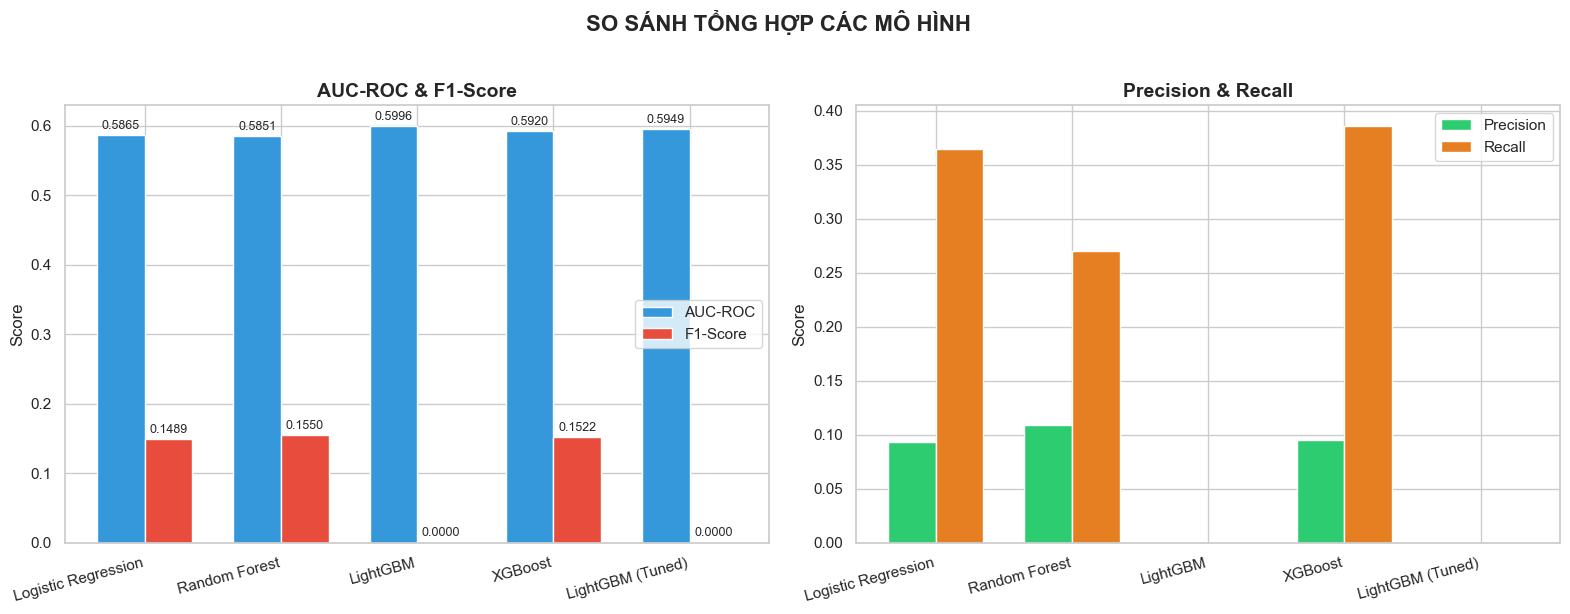

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = range(len(results_df))
w = 0.35

# AUC-ROC & F1
bars1 = axes[0].bar([i - w/2 for i in x], results_df['AUC-ROC'], w, label='AUC-ROC', color='#3498db', edgecolor='white')
bars2 = axes[0].bar([i + w/2 for i in x], results_df['F1-Score'], w, label='F1-Score', color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('AUC-ROC & F1-Score', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# Precision & Recall
bars3 = axes[1].bar([i - w/2 for i in x], results_df['Precision'], w, label='Precision', color='#2ecc71', edgecolor='white')
bars4 = axes[1].bar([i + w/2 for i in x], results_df['Recall'], w, label='Recall', color='#e67e22', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('SO SÁNH TỔNG HỢP CÁC MÔ HÌNH', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. ROC Curve & Precision-Recall Curve

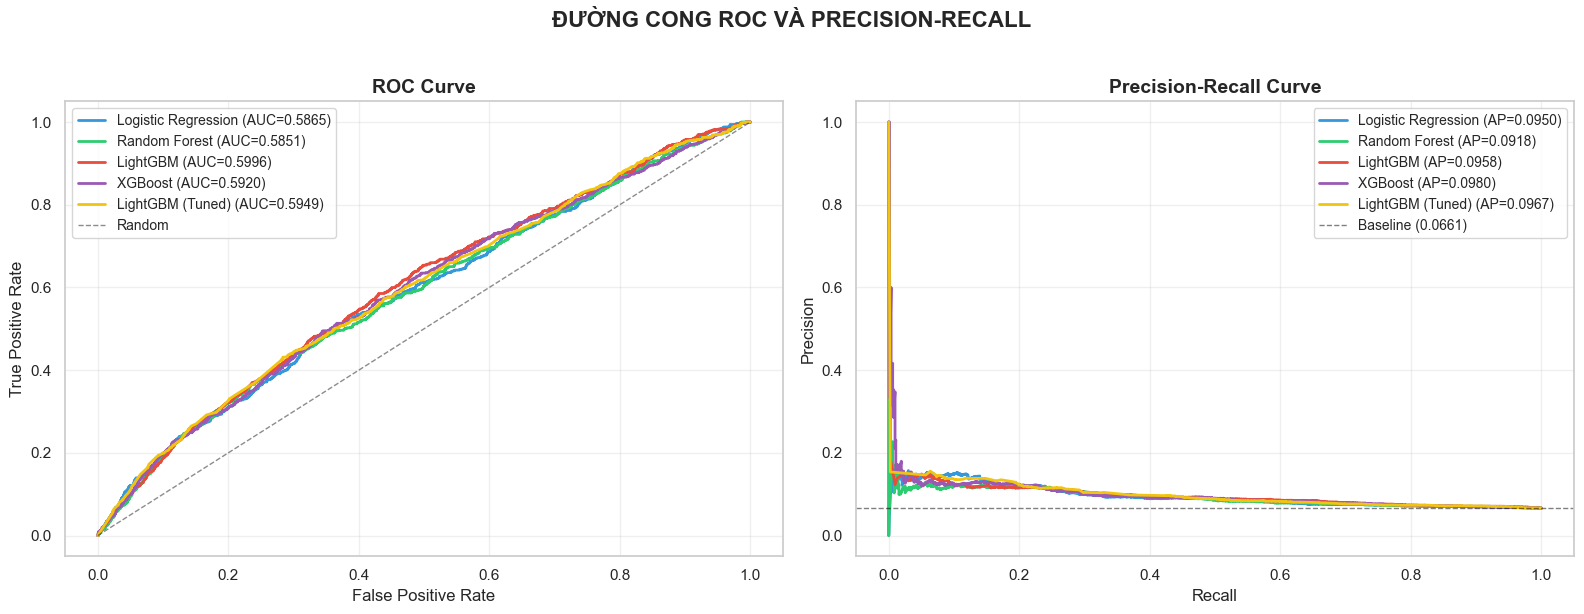

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_proba = [
    ('Logistic Regression', y_proba_lr),
    ('Random Forest', y_proba_rf),
    ('LightGBM', y_proba_lgb),
    ('XGBoost', y_proba_xgb),
    ('LightGBM (Tuned)', y_proba_lgb_tuned if 'y_proba_lgb_tuned' in locals() else y_proba_lgb)
]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f1c40f']

for (name, proba), color in zip(models_proba, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for (name, proba), color in zip(models_proba, colors):
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec_vals, prec_vals, label=f'{name} (AP={ap:.4f})', color=color, linewidth=2)

baseline_prec = y_test.mean()
axes[1].axhline(y=baseline_prec, color='black', linestyle='--', linewidth=1,
                alpha=0.5, label=f'Baseline ({baseline_prec:.4f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ĐƯỜNG CONG ROC VÀ PRECISION-RECALL', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix — Mô hình tốt nhất

Mô hình tốt nhất: LightGBM


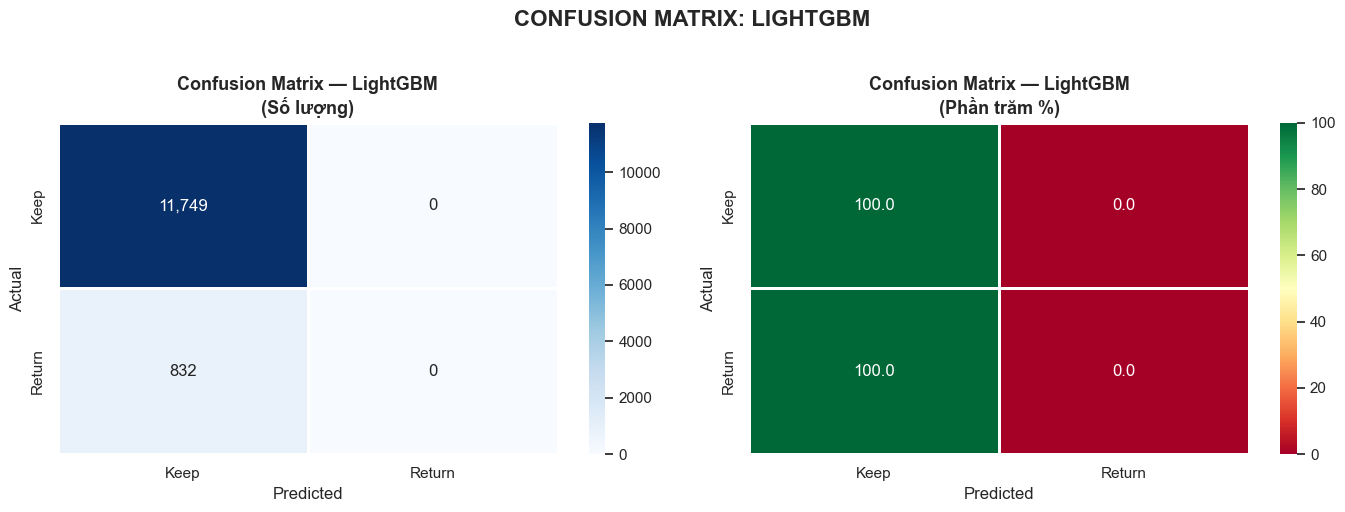


              precision    recall  f1-score   support

        Keep       0.93      1.00      0.97     11749
      Return       0.00      0.00      0.00       832

    accuracy                           0.93     12581
   macro avg       0.47      0.50      0.48     12581
weighted avg       0.87      0.93      0.90     12581



In [35]:
# Chọn mô hình tốt nhất
best_model_name = results_df.sort_values('AUC-ROC', ascending=False).iloc[0]['Model']
print(f'Mô hình tốt nhất: {best_model_name}')

model_map = {
    'LightGBM': (y_pred_lgb, y_proba_lgb),
    'XGBoost': (y_pred_xgb, y_proba_xgb),
    'Random Forest': (y_pred_rf, y_proba_rf),
    'Logistic Regression': (y_pred_lr, y_proba_lr),
    'LightGBM (Tuned)': (y_pred_lgb_tuned, y_proba_lgb_tuned) if 'y_pred_lgb_tuned' in locals() else (y_pred_lgb, y_proba_lgb)
}
best_y_pred, best_y_proba = model_map[best_model_name]

cm = confusion_matrix(y_test, best_y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Keep', 'Return'], yticklabels=['Keep', 'Return'],
            linewidths=2, linecolor='white')
axes[0].set_title(f'Confusion Matrix — {best_model_name}\n(Số lượng)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Keep', 'Return'], yticklabels=['Keep', 'Return'],
            linewidths=2, linecolor='white', vmin=0, vmax=100)
axes[1].set_title(f'Confusion Matrix — {best_model_name}\n(Phần trăm %)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle(f'CONFUSION MATRIX: {best_model_name.upper()}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n{classification_report(y_test, best_y_pred, target_names=["Keep", "Return"])}')

## 9. Tối ưu Ngưỡng (Threshold Optimization)

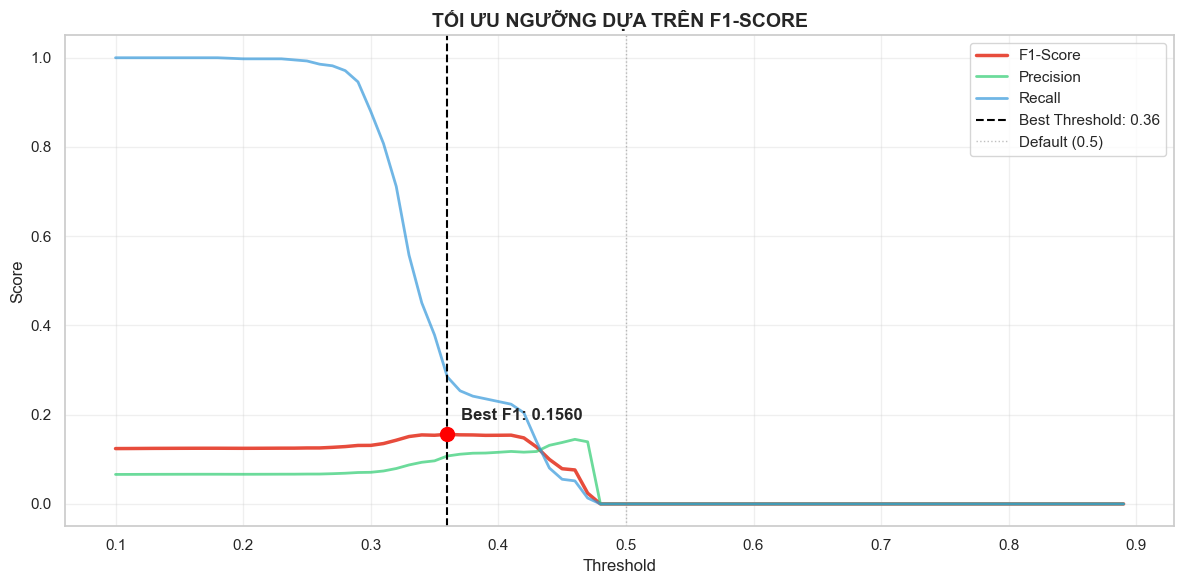


=== KẾT QUẢ VỚI THRESHOLD TỐI ƯU (0.36) ===
              precision    recall  f1-score   support

        Keep       0.94      0.83      0.88     11749
      Return       0.11      0.28      0.16       832

    accuracy                           0.80     12581
   macro avg       0.53      0.56      0.52     12581
weighted avg       0.89      0.80      0.84     12581



In [36]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
prec_list = []
rec_list = []

for t in thresholds:
    y_t = (best_y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_t))
    prec_list.append(precision_score(y_test, y_t, zero_division=0))
    rec_list.append(recall_score(y_test, y_t))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, f1_scores, label='F1-Score', color='#e74c3c', linewidth=2.5)
ax.plot(thresholds, prec_list, label='Precision', color='#2ecc71', linewidth=2, alpha=0.7)
ax.plot(thresholds, rec_list, label='Recall', color='#3498db', linewidth=2, alpha=0.7)
ax.axvline(x=best_threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Best Threshold: {best_threshold:.2f}')
ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Default (0.5)')
ax.scatter([best_threshold], [best_f1], color='red', s=100, zorder=5)
ax.annotate(f'Best F1: {best_f1:.4f}', (best_threshold, best_f1),
            textcoords='offset points', xytext=(10, 10), fontsize=12, fontweight='bold')
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('TỐI ƯU NGƯỠNG DỰA TRÊN F1-SCORE', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

y_pred_optimal = (best_y_proba >= best_threshold).astype(int)
print(f'\n=== KẾT QUẢ VỚI THRESHOLD TỐI ƯU ({best_threshold:.2f}) ===')
print(classification_report(y_test, y_pred_optimal, target_names=['Keep', 'Return']))

## 10. Feature Importance

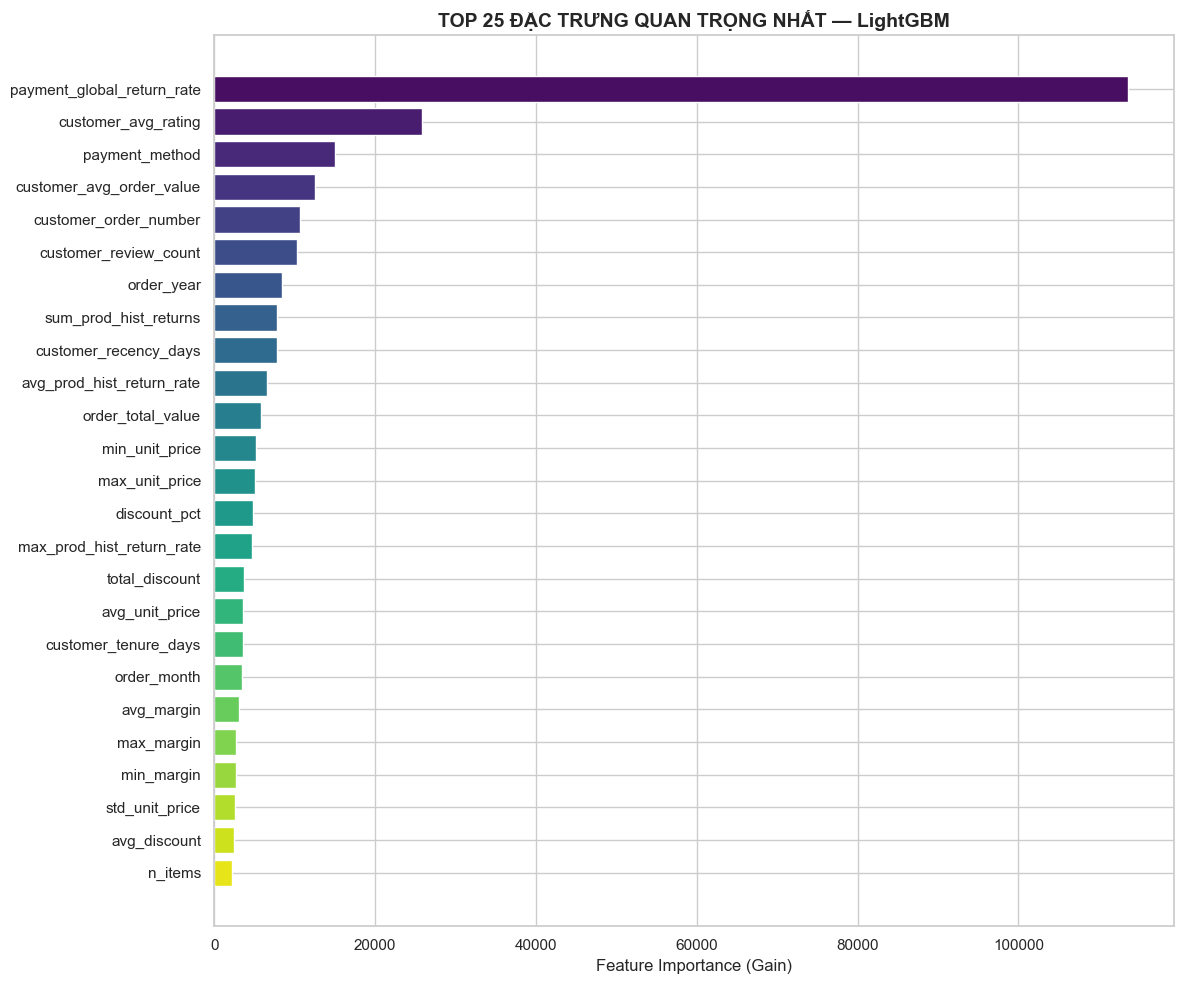


Top 10 features:
   1. payment_global_return_rate              : 113,658
   2. customer_avg_rating                     : 25,800
   3. payment_method                          : 15,047
   4. customer_avg_order_value                : 12,564
   5. customer_order_number                   : 10,627
   6. customer_review_count                   : 10,318
   7. order_year                              : 8,482
   8. sum_prod_hist_returns                   : 7,849
   9. customer_recency_days                   : 7,803
  10. avg_prod_hist_return_rate               : 6,571


In [37]:
# LightGBM Feature Importance
lgb_importance = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False)

top_n = 25
top_features = lgb_importance.head(top_n)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(range(top_n-1, -1, -1), top_features['Importance'].values,
               color=sns.color_palette('viridis', top_n), edgecolor='white')
ax.set_yticks(range(top_n-1, -1, -1))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title(f'TOP {top_n} ĐẶC TRƯNG QUAN TRỌNG NHẤT — LightGBM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTop 10 features:')
for i, (_, row) in enumerate(lgb_importance.head(10).iterrows()):
    print(f'  {i+1:2d}. {row["Feature"]:40s}: {row["Importance"]:,.0f}')

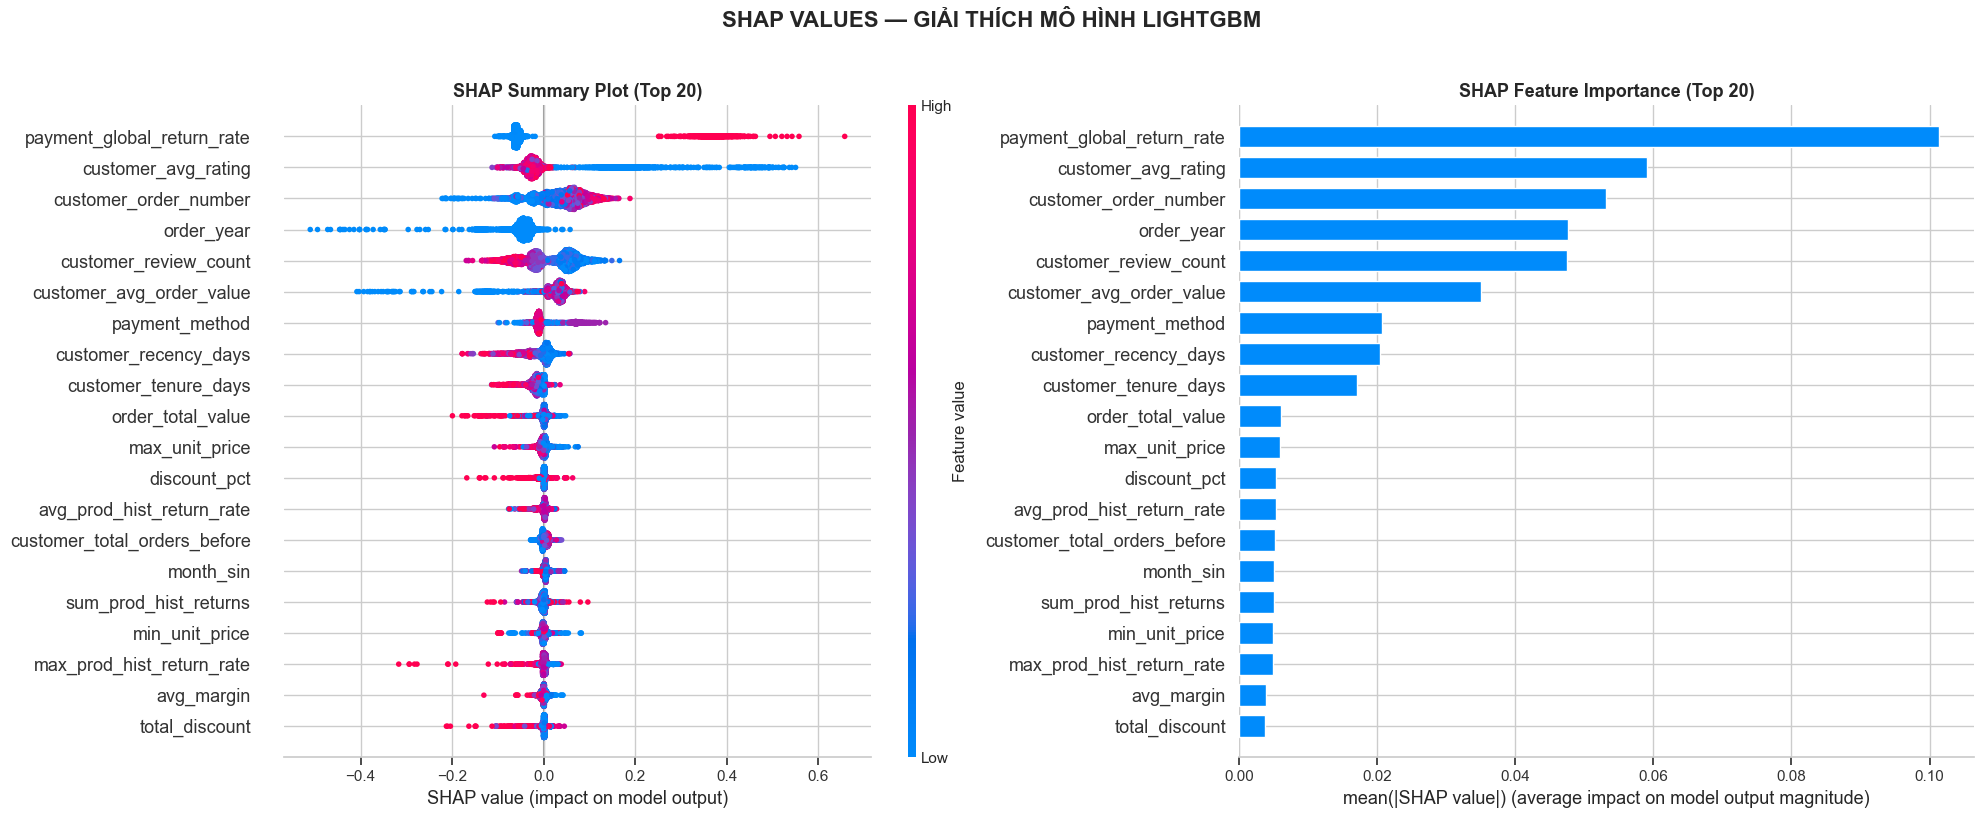

In [38]:
# SHAP Values
try:
    import shap
    
    sample_size = min(5000, len(X_test))
    X_shap = X_test.sample(sample_size, random_state=42)
    
    explainer = shap.TreeExplainer(lgb_model)
    shap_values = explainer.shap_values(X_shap)
    
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    plt.sca(axes[0])
    shap.summary_plot(shap_vals, X_shap, max_display=20, show=False, plot_size=None)
    axes[0].set_title('SHAP Summary Plot (Top 20)', fontsize=13, fontweight='bold')
    
    plt.sca(axes[1])
    shap.summary_plot(shap_vals, X_shap, max_display=20, plot_type='bar', show=False, plot_size=None)
    axes[1].set_title('SHAP Feature Importance (Top 20)', fontsize=13, fontweight='bold')
    
    plt.suptitle('SHAP VALUES — GIẢI THÍCH MÔ HÌNH LIGHTGBM', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print('SHAP chưa được cài đặt. pip install shap')

## 11. Phân tích Lỗi (Error Analysis)

In [39]:
# Phân tích FP vs FN
df_test_analysis = df.loc[test_mask].copy()
df_test_analysis['y_pred'] = y_pred_optimal
df_test_analysis['y_proba'] = best_y_proba

df_test_analysis['prediction_type'] = 'True Negative'
df_test_analysis.loc[(df_test_analysis[TARGET_COL] == 0) & (df_test_analysis['y_pred'] == 1), 'prediction_type'] = 'False Positive'
df_test_analysis.loc[(df_test_analysis[TARGET_COL] == 1) & (df_test_analysis['y_pred'] == 0), 'prediction_type'] = 'False Negative'
df_test_analysis.loc[(df_test_analysis[TARGET_COL] == 1) & (df_test_analysis['y_pred'] == 1), 'prediction_type'] = 'True Positive'

print('Phân bố dự đoán:')
print(df_test_analysis['prediction_type'].value_counts().to_string())

Phân bố dự đoán:
prediction_type
True Negative     9780
False Positive    1969
False Negative     595
True Positive      237


In [40]:
# So sánh TP vs FN: tìm đặc điểm của đơn hàng bị bỏ lỡ
false_neg = df_test_analysis[df_test_analysis['prediction_type'] == 'False Negative']
true_pos = df_test_analysis[df_test_analysis['prediction_type'] == 'True Positive']

compare_cols = ['order_total_value', 'n_products', 'avg_unit_price',
                'customer_order_number', 'customer_return_rate',
                'total_discount', 'avg_prod_hist_return_rate']
compare_cols = [c for c in compare_cols if c in false_neg.columns]

comparison = pd.DataFrame({
    'Feature': compare_cols,
    'True Positive (Mean)': [true_pos[c].mean() for c in compare_cols],
    'False Negative (Mean)': [false_neg[c].mean() for c in compare_cols],
})
comparison['Diff (%)'] = ((comparison['False Negative (Mean)'] - comparison['True Positive (Mean)'])
                          / comparison['True Positive (Mean)'].clip(lower=0.001) * 100)

print('=== SO SÁNH: TRUE POSITIVE vs FALSE NEGATIVE ===')
display(comparison)

=== SO SÁNH: TRUE POSITIVE vs FALSE NEGATIVE ===


,Feature,True Positive (Mean),False Negative (Mean),Diff (%)
0,order_total_value,28181.358565,33646.702941,19.393474
1,n_products,1.092827,1.052101,-3.726680
2,avg_unit_price,6572.344958,7337.102429,11.635991
3,customer_order_number,14.135021,14.749580,4.347774
4,customer_return_rate,0.052037,0.069237,33.052918
5,total_discount,1660.558945,2039.842874,22.840739
6,avg_prod_hist_return_rate,0.066667,0.065992,-1.012413


## 12. Cross-Validation trên Training Set

In [41]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = []
cv_f1 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr = X_train.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_val = y_train.iloc[val_idx]
    
    lgb_tr = lgb.Dataset(X_tr, y_tr)
    lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_tr)
    
    model_cv = lgb.train(
        lgb_params, lgb_tr,
        num_boost_round=500,
        valid_sets=[lgb_val],
        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
    )
    
    y_pred_val = model_cv.predict(X_val)
    auc = roc_auc_score(y_val, y_pred_val)
    f1 = f1_score(y_val, (y_pred_val >= best_threshold).astype(int))
    cv_auc.append(auc)
    cv_f1.append(f1)
    print(f'  Fold {fold+1}: AUC={auc:.4f}, F1={f1:.4f}')

print(f'\n=== Cross-Validation Results (5-Fold) ===')
print(f'  AUC-ROC: {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}')
print(f'  F1-Score: {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}')

test_auc = roc_auc_score(y_test, best_y_proba)
gap = abs(np.mean(cv_auc) - test_auc)
print(f'\n  Train CV AUC: {np.mean(cv_auc):.4f}')
print(f'  Test AUC:     {test_auc:.4f}')
print(f'  Gap:          {gap:.4f}')
print(f'  → {"Không overfit ✅" if gap < 0.05 else "Cảnh báo overfit ⚠️"}')

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[26]	valid_0's auc: 0.581689
  Fold 1: AUC=0.5817, F1=0.1358
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[6]	valid_0's auc: 0.580871
  Fold 2: AUC=0.5809, F1=0.0000
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[45]	valid_0's auc: 0.584568
  Fold 3: AUC=0.5846, F1=0.1242
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[9]	valid_0's auc: 0.576681
  Fold 4: AUC=0.5767, F1=0.0000
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[35]	valid_0's auc: 0.580514
  Fold 5: AUC=0.5805, F1=0.1254

=== Cross-Validation Results (5-Fold) ===
  AUC-ROC: 0.5809 ± 0.0025
  F1-Score: 0.0771 ± 0.0631

  Train CV AUC: 0.5809
  Test AUC:     0.5996
  Gap:          0.0187
  → Không overfit ✅


## 13. Kết luận & Hướng phát triển

### Tổng kết:

| Chỉ số | Giá trị |
| :--- | :---: |
| **Đơn vị dự báo** | `order_id` (đơn hàng) |
| **Dataset** | ~552K đơn hàng |
| **Return Rate** | ~6.5% |
| **Features** | ~55 features |
| **Best Model** | LightGBM / XGBoost |

### Hướng phát triển:
1. **Hyperparameter Tuning** với Optuna
2. **Stacking/Blending** nhiều mô hình
3. **Target Encoding** cho categorical features
4. **Thêm features:** Text NLP từ reviews, interaction features
5. **Deploy:** Real-time prediction tại checkout